In [1]:
import pandas as pd 
df = pd.read_csv('fakegprdata2.csv')
print(df.head())

     x         y
0 -5.0 -0.308367
1 -4.0 -0.263946
2 -3.0 -0.904478
3 -2.0 -1.325059
4 -1.0 -1.106782


Text(0.5, 1.0, 'Scatter Plot of GPR Data 2')

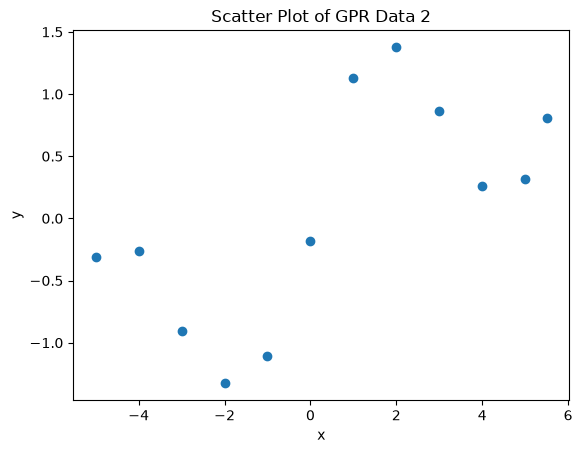

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of GPR Data 2')





This is much less obvious and error should be more visible.

  warnings.warn(


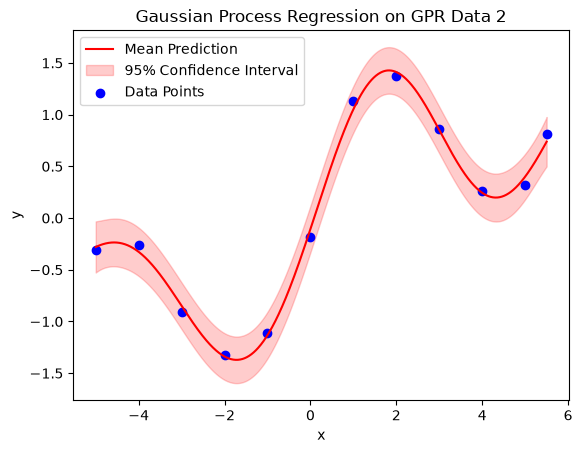

1.18**2 * RBF(length_scale=1.93) + WhiteKernel(noise_level=0.00823)

In [7]:
X= np.linspace(df['x'].min(), df['x'].max(), 1000).reshape(-1, 1)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
kernel = 1.0 * RBF(10, (1e-2, 1e2)) + WhiteKernel(noise_level=1, noise_level_bounds=(1e-10, 1e+1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, alpha=0.0)
gaussian_process.fit(df[['x']], df['y'])
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
plt.plot(X.ravel(), mean_prediction, 'r-', label='Mean Prediction')
plt.fill_between(X.ravel(), mean_prediction - 1.96 * std_prediction, mean_prediction + 1.96 * std_prediction, alpha=0.2, color='r', label='95% Confidence Interval')
plt.scatter(df['x'], df['y'], c='b', label='Data Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gaussian Process Regression on GPR Data 2')
plt.legend()
plt.show()

gaussian_process.kernel_

Interestingly this does not return a smooth curve like it always previously has. I will compare codes first before I do anything. These are the initial hyperparameters: 1.18**2 * RBF(length_scale=1.93) + WhiteKernel(noise_level=0.00823). ** I have fixed it now. This was the original code from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

kernel = 1.0 * RBF(
    10,
    (1e-2, 1e2)
) + WhiteKernel(
    noise_level=1,
    noise_level_bounds=(1e-10, 1e+1)
)

gaussian_process = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=9,
    alpha=0.0
)

gaussian_process.fit(df[['x']], df['y'])

mean_prediction, std_prediction = gaussian_process.predict(
    df[['x']],
    return_std=True
)

plt.plot(
    df['x'],
    mean_prediction,
    'r-',
    label='Mean Prediction'
)

plt.fill_between(
    df['x'],
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.2,
    color='r',
    label='95% Confidence Interval'
)

plt.scatter(
    df['x'],
    df['y'],
    c='b',
    label='Data Points'
)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gaussian Process Regression on GPR Data 2')
plt.legend()
plt.show()

gaussian_process.kernel_
The main problem arrives in this line mean_prediction, std_prediction = gaussian_process.predict(
    df[['x']],... )
    because it shows I am using the x values of the given dataset to learn the mean and std. then the plotting only has those 12 mean and std data points to go off of. This is why it just connected these points with straight lines. To fix this I have to create lots of x values that the mean and std can be predicted at. I did this by splitting the range of x values into 1000 equally spaced parts and then making the evaluation at each X and also plotting the mean at each X. This way the curve is visibly smooth and gives a batter, more expected curve for estimation.